## EXPLORING THE CCM DATA

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from ipywidgets import interact, interactive
from IPython.display import display

In [37]:
CCM = pd.read_parquet(r'C:\Users\zkx14\Downloads\CCM_dataset\CCM.parquet')

In [38]:
CCM.head()

,gvkey,fyear,datadate,permno,permco,at,sale,prcc_f,csho,ni,...,Industry,date,ret,vol,prc,shrout,sprtrn,vwretd,ewretd,retx
0,1000,1970,1970-12-31,25881,23369,33.45,45.335,10.0,2.446,0.558,...,NaN,1971-03-31,-12.3596,206200.0,9.750,2655.0,3.6796,0.0,5.6603,-12.3596
1,1000,1970,1970-12-31,25881,23369,33.45,45.335,10.0,2.446,0.558,...,NaN,1971-04-30,10.2564,143300.0,10.750,2655.0,3.6288,0.0,2.7087,10.2564
2,1000,1970,1970-12-31,25881,23369,33.45,45.335,10.0,2.446,0.558,...,NaN,1971-05-28,-19.7674,79600.0,8.625,2655.0,-4.1558,0.0,-4.9435,-19.7674
3,1000,1970,1970-12-31,25881,23369,33.45,45.335,10.0,2.446,0.558,...,NaN,1971-06-30,-4.3478,57200.0,8.250,2655.0,0.0703,0.0,-1.7240,-4.3478
4,1000,1970,1970-12-31,25881,23369,33.45,45.335,10.0,2.446,0.558,...,NaN,1971-07-30,-25.7576,37100.0,6.125,2655.0,-4.1324,0.0,-5.3634,-25.7576


Here it has a lot of columns but right now we only take the columns 'permno', 'date', 'ret', 'prc', 'shrout' as the final goals needs only these columns

* permno: A permanent security identifier assigned by CRSP to each individual security (issue). It does not change over time and is not reused.

* ret: The stock return for that security over the period ending on that date, usually including dividends and splits. 
        5% return = 0.05 ret
        120% return = 1.20 ret

* shrout: The number of shares outstanding for that security on that date

In [39]:
data = CCM[['permno','date','ret','prc','shrout','sale']]

In [40]:
data.head()

,permno,date,ret,prc,shrout,sale
0,25881,1971-03-31,-12.3596,9.750,2655.0,45.335
1,25881,1971-04-30,10.2564,10.750,2655.0,45.335
2,25881,1971-05-28,-19.7674,8.625,2655.0,45.335
3,25881,1971-06-30,-4.3478,8.250,2655.0,45.335
4,25881,1971-07-30,-25.7576,6.125,2655.0,45.335


In [41]:
# Ensure correct dtypes
data['date'] = pd.to_datetime(data['date'])
data['ret'] = pd.to_numeric(data['ret'], errors='coerce')
data['prc'] = pd.to_numeric(data['prc'], errors='coerce')
data['shrout'] = pd.to_numeric(data['shrout'], errors='coerce')

In [42]:
data.shape

(3060413, 6)

In [43]:
data.head()

,permno,date,ret,prc,shrout,sale
0,25881,1971-03-31,-12.3596,9.750,2655.0,45.335
1,25881,1971-04-30,10.2564,10.750,2655.0,45.335
2,25881,1971-05-28,-19.7674,8.625,2655.0,45.335
3,25881,1971-06-30,-4.3478,8.250,2655.0,45.335
4,25881,1971-07-30,-25.7576,6.125,2655.0,45.335


In [44]:
data.isna().sum()

permno        0
date          0
ret           0
prc           0
shrout        0
sale      11932
dtype: int64

# Exploratory data analysis

In [45]:
max_value = data['ret'].max()
min_value = data['ret'].min()

# Count how many times they appear
min_count = (data['ret'] == min_value).sum()
max_count = (data['ret'] == max_value).sum()

print(f"Lowest return: {min_value}, appears {min_count} times")
print(f"Highest return: {max_value}, appears {max_count} times")

Lowest return: -100.0, appears 7 times
Highest return: 2658.3827, appears 1 times


In [46]:
# Get the 10 lowest returns and their counts
lowest_10 = data['ret'].value_counts().sort_index().head(25)
print("Lowest 10 returns and their frequency:\n", lowest_10)

# Get the 10 highest returns and their counts
highest_10 = data['ret'].value_counts().sort_index(ascending=False).head(25)
print("\nHighest 10 returns and their frequency:\n", highest_10)

Lowest 10 returns and their frequency:
 ret
-100.0000    7
-99.5833     1
-99.3600     1
-98.4026     1
-98.1295     1
-98.0000     1
-97.8164     1
-97.6126     1
-97.4563     1
-97.3684     1
-97.2173     1
-97.1319     1
-96.8292     1
-96.5789     1
-96.4689     1
-96.4286     1
-96.4198     1
-96.2857     1
-96.2486     1
-96.1852     1
-96.1538     1
-96.1087     1
-96.0395     1
-95.9144     1
-95.9091     1
Name: count, dtype: int64

Highest 10 returns and their frequency:
 ret
2658.3827    1
2400.0000    1
2225.0870    1
1988.3590    1
1948.6034    1
1900.0000    1
1791.6667    1
1760.4651    1
1625.0531    1
1598.4456    1
1577.4194    1
1445.8015    1
1400.0000    1
1389.8000    1
1349.5050    1
1266.6667    1
1250.0000    1
1247.8261    1
1245.5858    1
1238.7097    1
1222.9025    1
1180.0000    1
1130.1676    1
1102.1277    1
1100.0000    1
Name: count, dtype: int64


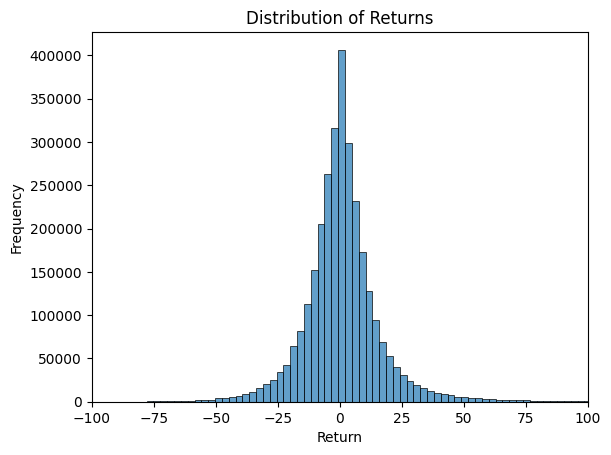

In [47]:
# Making a histigram to understand the overall markets return distribution
plt.hist(data['ret'], bins=1000, edgecolor='black', alpha=0.7, linewidth=0.7)
plt.xlim(-100, 100) 
plt.xlabel('Return')
plt.ylabel('Frequency')
plt.title('Distribution of Returns')
plt.show()

* Returns are centered near zero → The average period return is close to zero, indicating most stock price changes are small gains or losses over the sample period.

* Approximately bell-shaped and normal distribution

* Possible slight negative skewness → Large negative returns appear somewhat more frequent or severe than large positive returns, consistent with downside risk asymmetry in equities.

* Presence of extreme returns → The dataset contains outliers with very large positive and negative returns, often due to corporate events like delistings, bankruptcies, or mergers.

## Equally-weighted portfolio

In Short, Equall weighted portfolio is like investing same amount of money in all the stocks available to you or in your tradable universe and all capital is allocated.

Here, weight(w) = 1/N , where N is the number of stock availabe to trade

Portfolio return = sum of the multiple of the weights and return of all the stocks at a speciic date. 

To build the equally weighted portfolio we need,
    "permo", "date", "ret"

In [48]:
ew = data[['permno','date','ret' ]]

In [49]:
ew.head()

,permno,date,ret
0,25881,1971-03-31,-12.3596
1,25881,1971-04-30,10.2564
2,25881,1971-05-28,-19.7674
3,25881,1971-06-30,-4.3478
4,25881,1971-07-30,-25.7576


In [50]:
ew.isna().sum()

permno    0
date      0
ret       0
dtype: int64

In [51]:
ew.info()

<class 'pandas.DataFrame'>
RangeIndex: 3060413 entries, 0 to 3060412
Data columns (total 3 columns):
 #   Column  Dtype         
---  ------  -----         
 0   permno  int64         
 1   date    datetime64[us]
 2   ret     float64       
dtypes: datetime64[us](1), float64(1), int64(1)
memory usage: 70.0 MB


In [52]:
"""
We now have to find out if we inversted 1 dollars on a equally weighted portfolio what would be the return

For that at first we need to know how the returns are of all the stocks and for that we groupby the date,
    .groupby("date", as_index = False) gives the permo and ret of a single date

since we have all the stocks and their returns for a specific date now we find the mean of the returns which
is done by the code line .agg(EW_ret = ('ret', 'mean'))

In short, ew_port groups the stock and return for a each specific date and then does the mean for all the returns
in that specific date hence giving a single float which can be used to calculate the portfolio's return

"""

ew_port = (
    ew
    .groupby('date', as_index=False)   # group all stocks by date
    .agg(EW_ret=('ret', 'mean'))      # average of ret = equally weighted return
)

In [53]:
# Cumulative return to $1 investment

# sort by date 
ew_port = ew_port.sort_values('date').reset_index(drop=True)

# returns are in percent, so converting to gross return
ew_port['ret_plus1'] = 1 + ew_port['EW_ret'] / 100.0

# cumulative product → value of $1 over time
ew_port['cumRet'] = ew_port['ret_plus1'].cumprod()

print(ew_port.head())
print(ew_port[['EW_ret']].describe())

        date    EW_ret  ret_plus1    cumRet
0 1950-09-29  7.732648   1.077326  1.077326
1 1950-10-31 -0.077768   0.999222  1.076489
2 1950-11-30  2.261112   1.022611  1.100829
3 1950-12-30  7.135907   1.071359  1.179383
4 1951-01-31  7.261237   1.072612  1.265021
           EW_ret
count  904.000000
mean     1.208449
std      5.634678
min    -28.777435
25%     -1.985858
50%      1.393403
75%      4.371450
max     30.387423


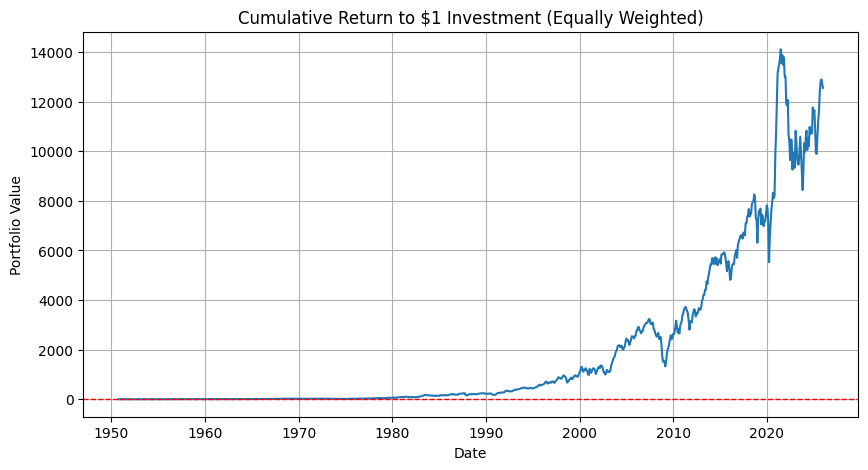

In [54]:
plt.figure(figsize=(10,5))
plt.plot(ew_port['date'], ew_port['cumRet'])
plt.axhline(1.0, color='red', linestyle='--', linewidth=1)
plt.title('Cumulative Return to $1 Investment (Equally Weighted)')
plt.xlabel('Date')
plt.ylabel('Portfolio Value')
plt.grid(True)
plt.show()

## Value weighted Portfolio

In short, bigger companies get bigger weights and is based on their market capitalization.

For this notebook, market cap is recalulated and the weights are adjusted every month.

So, 
* at the end of the month(t-1) we compute the mean of the stock's market cap, i.e. mrktCap = price * shares
* at the start of the month(t) we recalculate the weights and readjust the weights
* at the end of the month(t) we recompute the market cap
 


In [ ]:
"""
We now want to find out what happens if we invest 1 dollar in a value weighted portfolio.

For that, we first need the market capitalization of each stock, which is calculated as
price × shares outstanding. This is done by:

    vw_df['mktCap'] = vw_df['prc'] * vw_df['shrout']

After that, we sort by permno and date and compute the lagged market cap using
.shift(1). We use the lagged value because portfolio weights at time t must be
based on information available at time t-1.

Next, we group by date and sum all lagged market caps using:

    .groupby('date')['mktCap_lag'].transform('sum')

This gives us the total market capitalization of all stocks for each specific date.

Now we calculate the weight of each stock in the portfolio:

    w(i,t) = mktCap_lag(i,t) / total_mktCap(t)

Then we multiply each stock’s weight by its return:

    w_ret(i,t) = w(i,t) * ret(i,t)

Finally, we group by date again and sum all weighted returns:

    .groupby('date').agg(VW_ret=('w_ret','sum'))

This gives us one single portfolio return per date, but now it is value weighted
instead of equally weighted.

To see what happens if we invested 1 dollar, we convert returns into gross returns
(1 + return) and take the cumulative product. This shows how the value of the
portfolio evolves over time.
"""
vw_df = data.copy()

# Computing market capitalization (price × shares outstanding)
vw_df['mktCap'] = vw_df['prc'] * vw_df['shrout']

# Lagged market cap by stock
vw_df = (
    vw_df
    .sort_values(['permno', 'date'])
    .assign(
        mktCap_lag = lambda df: df.groupby('permno')['mktCap'].shift(1) # shift(1) moves marketcap down by one row
    )
)

# Drop rows without lagged market cap
vw_df = vw_df[vw_df['mktCap_lag'].notna()].copy()

# Computing total lagged market cap across all stocks for each date
vw_df['all_mktCap'] = (
    vw_df
    .groupby('date')['mktCap_lag']
    .transform('sum')
)

# Value weights and weighted returns
#    w(i,t)     = mktCap_lag(i,t) / all_mktCap(t)
#    w_ret(i,t) = w(i,t) * ret(i,t)

vw_df['w'] = vw_df['mktCap_lag'] / vw_df['all_mktCap']
vw_df['w_ret'] = vw_df['w'] * vw_df['ret']

# Aggregate weighted returns across stocks to get portfolio return per date
vw_port = (
    vw_df
    .groupby('date', as_index=False)
    .agg(
        VW_ret = ('w_ret', 'sum')
    )
)

# computing cumulative portfolio return
vw_port = vw_port.sort_values('date').reset_index(drop=True)
vw_port['VW_plus1'] = 1 + vw_port['VW_ret'] / 100.0
vw_port['VW_cumRet'] = vw_port['VW_plus1'].cumprod()


In [56]:
print(vw_port.head())

        date    VW_ret  VW_plus1  VW_cumRet
0 1950-10-31  0.363744  1.003637   1.003637
1 1950-11-30  1.721683  1.017217   1.020917
2 1950-12-30  4.847294  1.048473   1.070404
3 1951-01-31  6.898221  1.068982   1.144243
4 1951-02-28  1.251855  1.012519   1.158567


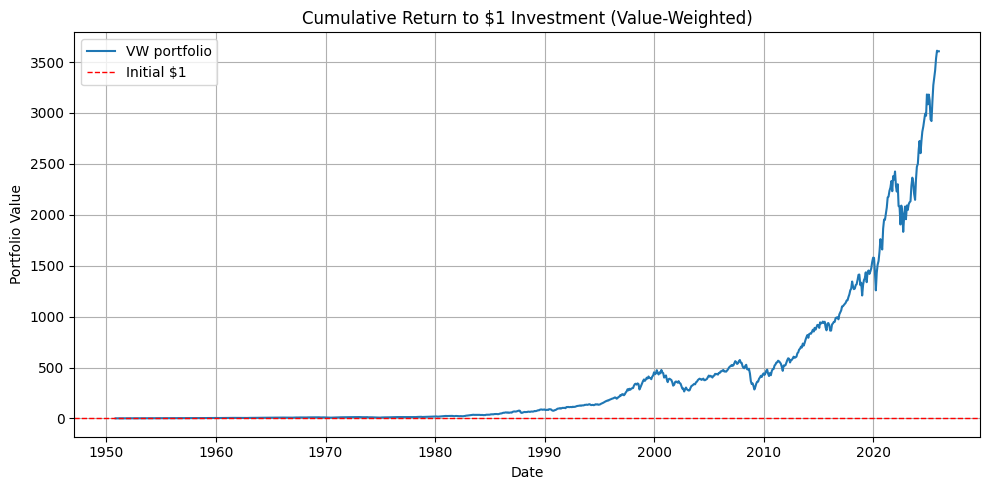

In [57]:
plt.figure(figsize=(10, 5))
plt.plot(vw_port['date'], vw_port['VW_cumRet'], label='VW portfolio')
plt.axhline(1.0, color='red', linestyle='--', linewidth=1, label='Initial $1')

plt.title('Cumulative Return to $1 Investment (Value-Weighted)')
plt.xlabel('Date')
plt.ylabel('Portfolio Value')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


## Combined graph

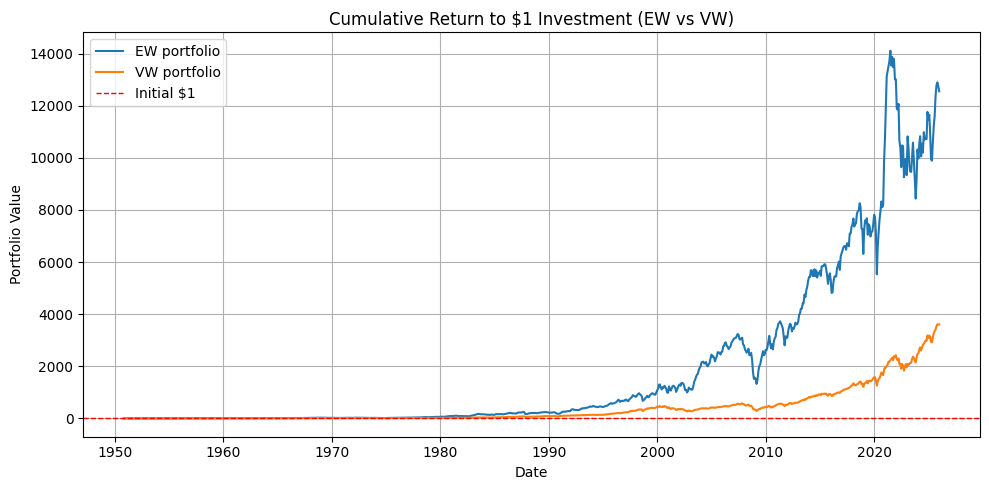

In [58]:
both = ew_port[['date', 'cumRet']].rename(columns={'cumRet': 'EW_cumRet'})
both = both.merge(
    vw_port[['date', 'VW_cumRet']],
    on='date',
    how='inner'
)

# Plot cumulative $1 for EW and VW together
plt.figure(figsize=(10, 5))

plt.plot(both['date'], both['EW_cumRet'], label='EW portfolio')
plt.plot(both['date'], both['VW_cumRet'], label='VW portfolio')

plt.axhline(1.0, color='red', linestyle='--', linewidth=1, label='Initial $1')

plt.title('Cumulative Return to $1 Investment (EW vs VW)')
plt.xlabel('Date')
plt.ylabel('Portfolio Value')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()